In [1]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import scanpy as sc
import pandas as pd
import anndata as ad
from tqdm import tqdm
from scipy import sparse
import scipy.sparse as sp
import gc
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')
import sklearn

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/tabula_muris_brain/low_dimensional_rep
scanpy==1.9.3 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.0.1 statsmodels==0.13.1 python-igraph==0.10.4 pynndescent==0.5.8


In [2]:
import torch 
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cpu


In [3]:
import sys
sys.path.append('../../utils')
from functions import * 

leaflet_repo = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(leaflet_repo)
import load_cluster_data
from betabinomo_mix_singlecells import *

In [4]:
from importlib import reload
import sys

# Replace 'PATH_TO_REPOSITORY' with the actual path to the repository containing load_cluster_data.py
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/archive/beta-binomial-lda/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [5]:
# Now you can import the module
import splicing_PCA_utils
from splicing_PCA_utils import make_Y

import nuclear_norm_PCA as knuckle # knuckle: Konvex NUClear norm Konstrained Linear Embedding
import splicing_PCA_utils 

In [6]:
# this folder contains input data for each tissue cell type sample
#input_files_folder = '/gpfs/commons/scratch/kisaev/ss_tabulamuris_test/Leaflet/Brain/'

input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'
cell_types = ['Brain_Non-Myeloid_brain_pericyte',
 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell',
 'Brain_Non-Myeloid_endothelial_cell' 'Brain_Non-Myeloid_oligodendrocyte',
 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage',
 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']#ignoring Bergmann_glial_cell since very few cells

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, celltypes=cell_types, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/
Finished reading in data from folder ...
Looking at only specific cell types ...['Brain_Non-Myeloid_brain_pericyte', 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell', 'Brain_Non-Myeloid_endothelial_cellBrain_Non-Myeloid_oligodendrocyte', 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage', 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']
['Brain_Non-Myeloid_brain_pericyte'
 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'
 'Brain_Non-Myeloid_neuron' 'Brain_Myeloid_macrophage'
 'Brain_Myeloid_microglial_cell' 'Brain_Non-Myeloid_astrocyte']
5527
13952
The maximum junction count was initially:  36797
33
The maximum junction count is now:  4982
                                             cell_id  Cluster  Cluster_Counts  \
0  A14-MAA000581-3_10_M-1-1_Brain_Non-Myeloid_bra...        4              21   
1  A14-MAA000581-3_10_M-1-1_Brain_Non

also printing original indices of junctions we are keeping


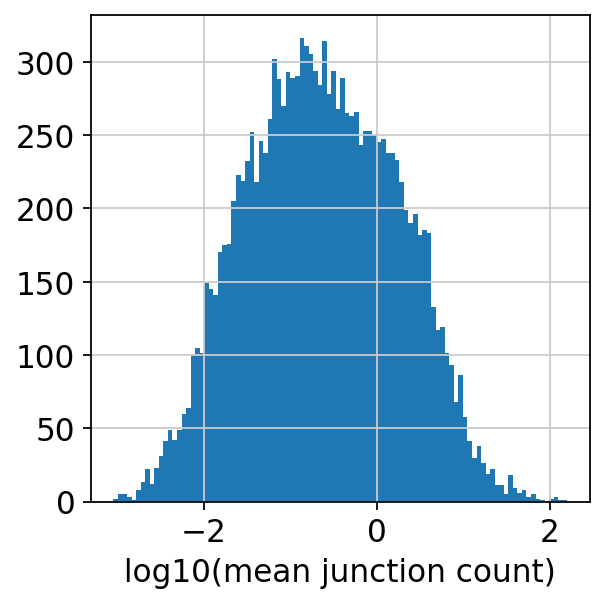

In [7]:
junc_counts_sub, cluster_counts_sub, junc_keep = splicing_PCA_utils.filter_junctions(
    junc_counts, cluster_counts, plot = True)

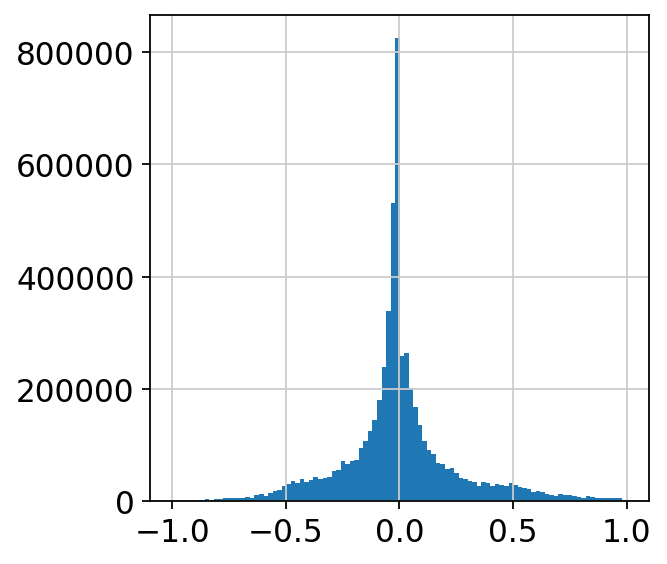

In [8]:
# set up data for nuc norm PCA
Y_data, w = splicing_PCA_utils.make_Y(
    junc_counts_sub, cluster_counts_sub, float_type)

# np.mean(Y_data * Y_data) * psi.shape[0] * psi.shape[1]
Y = torch.tensor(Y_data, **float_type)
W = torch.tensor(w.data, **float_type)

_ = plt.hist(Y_data, 100) # centered so the distribution peaks at 0 and is in [-1,1]

In [9]:
Y_train, W_train, indices_train, Y_test, W_test, indices_test = splicing_PCA_utils.train_test(
    Y_data, w, float_type)

In [ ]:
rmseTol = 5e-5
its=1

rs, testErrors, trainErrors, nuc_norms, final_svd, step_times = knuckle.constraint_search(
    indices_train, 
    Y_train, 
    W_train, 
    size = junc_counts_sub.shape,
    indices_test = indices_test, 
    Y_test = Y_test, 
    W_test = W_test, 
    rmseTol = rmseTol, 
    end = "\n",
    inner_verbose = True,
    power_iteration_controller = (30,1.),
    its = its,  
    **float_type)


In [ ]:
plt.plot(np.log10(rs), testErrors,"-o", label = "warmstart test")
plt.plot(np.log10(rs), trainErrors, "-o", label = "warmstart train")
plt.ylabel("RMSE")
plt.xlabel("log10(nuclear norm bound)")
plt.legend()

In [ ]:
plt.plot(final_svd.S)
plt.ylabel("Singular values of X") 
final_svd.S.sum()

In [ ]:
# solution is on the boundary up to about ~1e4, then is inside. 
plt.plot(np.log10(rs), np.log10(nuc_norms), "-o", label = "warmstart")
plt.xlabel("log10(Nuc norm bound)")
plt.ylabel("log10(Nuc norm obtained)")

In [ ]:
plt.plot(np.log10(nuc_norms), testErrors,"-o", label = "warmstart test")
plt.plot(np.log10(nuc_norms), trainErrors, "-o", label = "warmstart train")
plt.ylabel("RMSE")
plt.xlabel("log10(obtained nuclear norm)")
plt.legend()

In [ ]:
r_best = rs[np.argmin(testErrors)]
r_best

In [ ]:
r_best = 1.0e6 # minimal gains after this

In [ ]:
Y,W,indices = splicing_PCA_utils.to_torch(Y_data, w, **float_type)

In [ ]:
reload(knuckle)
rs, _, trainErrors_all, nuc_norms_all, final_svd_all, step_times = knuckle.constraint_search(
    indices, 
    Y, 
    W, 
    size = junc_counts_sub.shape,
    rmseTol = rmseTol, 
    its = its,  
    max_r = r_best, 
    end = "\n",
    **float_type)


In [ ]:
plt.plot(final_svd_all.S)

In [ ]:
# U_mat.T @ U_mat
import pandas as pd 
import seaborn as sns

PC_embed_df = pd.DataFrame({"PC1" : final_svd_all.U[:,0], "PC2" : final_svd_all.U[:,1]})
PC_embed_df["cell_type"] = cell_ids_conversion["cell_type"].to_numpy()
#p9.ggplot(X_embed_df, p9.aes(x = "x", y="y", color = "cell_type")) + p9.geom_point()

#plt.figure(figsize=[8,6]) # for pdf
plt.figure(figsize=[12,8])
sns.scatterplot(x = "PC1",y = "PC2", hue="cell_type", data= PC_embed_df, edgecolor = 'none', alpha = 0.1)

In [ ]:
final_svd_all.U
# convert to df and rename columns to be PCA_1, PCA_2, etc.
PC_df = pd.DataFrame(final_svd_all.U)
PC_df.columns = ["PCA_" + str(i) for i in range(1, PC_df.shape[1] + 1)]
PC_df["cell_type"] = cell_ids_conversion["cell_type"].to_numpy()
PC_df

In [ ]:
sns.scatterplot(x = "PCA_1",y = "PCA_3", hue="cell_type", data= PC_df, edgecolor = 'none', alpha = 0.1)

In [ ]:
pve = final_svd_all.S**2
pve /= pve.sum()
pve = pve.cumsum(0) * 100
plt.plot(pve)
plt.ylabel("Cumulative percent variance explained")
plt.ylim(0,100)

In [ ]:
def tsne_plot(E, cell_ids_conversion):

    PCs_embedded = sklearn.manifold.TSNE(
        n_components=2, 
        learning_rate='auto',
        init='random', 
        perplexity=30).fit_transform(E.numpy()) # scale by SVs?

    PC_embed_df = pd.DataFrame(PCs_embedded, columns = ["x","y"])
    PC_embed_df["cell_type"] = cell_ids_conversion["cell_type"].to_numpy()

    plt.figure(figsize=[12,8])
    sns.scatterplot(x = "x",y = "y", hue="cell_type", data= PC_embed_df, edgecolor = 'none', alpha = 0.1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel("tSNE 1")
    plt.ylabel("tSNE 2")
    ax = plt.gca()
    ax.set_xticks([])
    ax.set_yticks([])

In [ ]:
E = final_svd_all.U * final_svd_all.S

In [ ]:
tsne_plot(E, cell_ids_conversion)